# Modelagem

Neste primeiro notebook de modelagem, cria-se um modelo de séries temporais usando-se o mínimo de limpeza dos dados.


- Links uteis:

1 - https://theairlab.org/alfa-dataset/ (contém informações sobre o status do vôo.)

# Modelo básico


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Parâmetros

In [2]:
DATA_FILE = '../data/02_intermediate/carbonZ_2018-07-18-15-53-31_1_engine_failure_sem_cols_duplicadas.csv'

# Funções

In [3]:
# 1. Preparação dos Dados
def create_windows(df, window_size, features, target_col):
    X, y = [], []
    data = df[features].values
    labels = df[target_col].values
    
    for i in range(window_size, len(df)):
        # Pegamos as últimas 'window_size' linhas e achatamos em um vetor longo
        window = data[i-window_size:i].flatten()
        X.append(window)
        y.append(labels[i])
        
    return np.array(X), np.array(y)

# Modelagem

In [4]:
df = pd.read_csv(DATA_FILE)

In [5]:
# Vamos definir o tamanho da janela (ex: 20 amostras = 0.2s de história)
window_size = 20
target_col = 'target_fault'
features = [c for c in df.columns if c not in [target_col, 'timestamp']]

In [6]:
X, y = create_windows(df, window_size, features, target_col)

In [7]:
X

array([[ 124.17846993,   12.75270081,    0.20706232, ...,  -17.38635254,
           3.12066054, -120.35176086],
       [ 124.17846993,   12.75270081,    0.20706232, ...,  -17.38635254,
           3.12066054, -120.35176086],
       [ 124.17846993,   12.75270081,    0.20706232, ...,  -17.38635254,
           3.12066054, -120.35176086],
       ...,
       [   8.33748129,   21.67013741,    2.9582711 , ...,   -5.92437935,
          -1.28437495,    4.49645233],
       [   8.33748129,   21.67013741,    2.9582711 , ...,   -5.92437935,
          -1.28437495,    4.49645233],
       [   8.33748129,   21.67013741,    2.9582711 , ...,   -5.92437935,
          -1.28437495,    4.49645233]], shape=(25974, 1040))

Aviso: index 0 is out of bounds for axis 0 with size 0

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.59      1.00      0.74      4573
         1.0       0.00      0.00      0.00      3220

    accuracy                           0.59      7793
   macro avg       0.29      0.50      0.37      7793
weighted avg       0.34      0.59      0.43      7793



/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


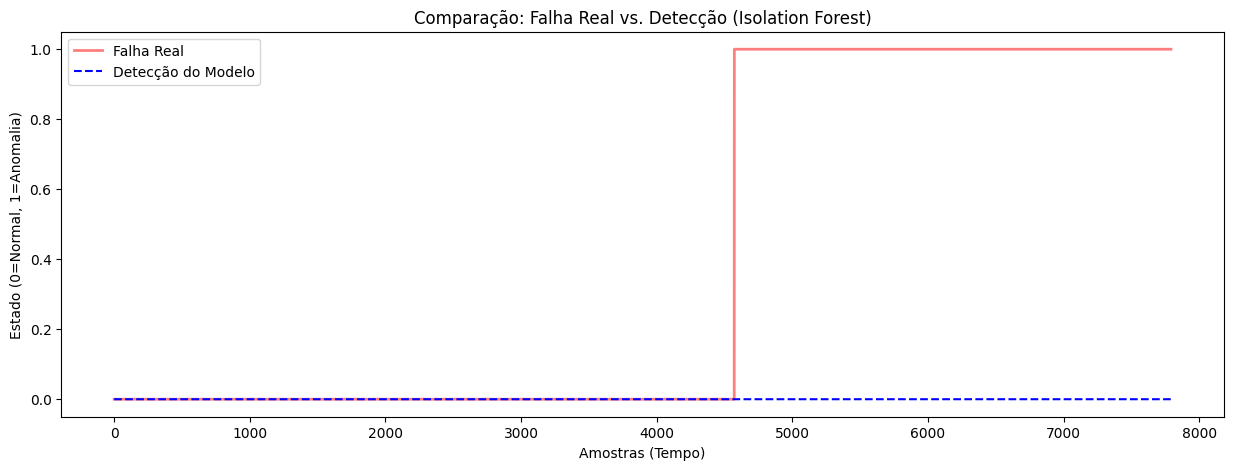

In [ ]:
# 3. Divisão de Treino e Teste
# Importante: Treinamos APENAS com dados onde target_fault == 0
# Vamos usar os primeiros 70% do voo, que sabemos ser nominal
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

# 4. Treinamento do Isolation Forest
# contamination: estimativa de anomalias no treino. Como o treino é nominal, 
# usamos um valor bem baixo (ex: 0.1%) apenas para robustez a ruído.
model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

test_timestamps = df['timestamp'].values[split + window_size:]

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(test_timestamps, y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(test_timestamps, y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()

Nenhuma anomalia encontrada.

# Selecionando as 10 features mais importantes - Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

# 1. Usar um modelo supervisionado rápido apenas para identificar relevância
# Aqui não precisamos de janelas, apenas os dados brutos linha a linha
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(df[features], df[target_col])

# 2. Criar um ranking das features
importances = pd.Series(rf_selector.feature_importances_, index=features)
top_features = importances.sort_values(ascending=False).head(10)

print("--- TOP 10 FEATURES MAIS RELEVANTES ---")
print(top_features)

# 3. Filtrar seu DataFrame para usar apenas essas 10
selected_features = top_features.index.tolist()
# Agora você pode rodar o Isolation Forest apenas com df_normalized[selected_features]

--- TOP 10 FEATURES MAIS RELEVANTES ---
aspd_hud           0.109759
aspd_meas          0.077940
alt_error          0.072027
alt_hud            0.071675
alt_global         0.063311
yaw_rate_target    0.056511
pos_z_local        0.049208
alt_gps_fix        0.039174
dev_path_z         0.037288
wind_y             0.035171
dtype: float64


- aspd_hud é a Velocidade do Ar consolidada que o sistema de voo apresenta para o piloto (ou operador) no painel principal. HUD refere-se a Heads-Up Display (Monitor de Transparência).

- yaw_rate_target: O Yaw (Guinada) é o movimento de girar o nariz do avião para a esquerda ou para a direita, como se o avião estivesse "olhando" para os lados sem inclinar as asas.

In [10]:
selected_features

['aspd_hud',
 'aspd_meas',
 'alt_error',
 'alt_hud',
 'alt_global',
 'yaw_rate_target',
 'pos_z_local',
 'alt_gps_fix',
 'dev_path_z',
 'wind_y']

In [11]:
# Criar a lista final de colunas que desejamos manter
cols_to_keep = selected_features + [target_col]

# 2. Filtrar o DataFrame original apenas com essas colunas
df_rf = df[cols_to_keep].copy()

print(f"Novo DataFrame criado com {df_rf.shape[1]} colunas.")
print(df_rf.head())

Novo DataFrame criado com 11 colunas.
    aspd_hud  aspd_meas  alt_error     alt_hud  alt_global  yaw_rate_target  \
0  18.193935  18.193935      -2.14  382.419983  347.412387       -18.193935   
1  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
2  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
3  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
4  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   

   pos_z_local  alt_gps_fix  dev_path_z    wind_y  target_fault  
0    37.247299   350.452363   12.752701  6.901174           0.0  
1    37.247299   350.452363   12.752701  6.901174           0.0  
2    37.247299   350.452363   12.752701  6.901174           0.0  
3    37.247299   350.452363   12.752701  6.901174           0.0  
4    37.247299   350.452363   12.752701  6.901174           0.0  


In [12]:
X, y = create_windows(df_rf, window_size, selected_features, target_col)

In [13]:
X

array([[ 18.19393539,  18.19393539,  -2.13999987, ..., 350.45236297,
         12.75270081,   6.90117376],
       [ 18.19393539,  18.21097946,  -2.13999987, ..., 350.45236297,
         12.75270081,   6.90117376],
       [ 18.19393539,  18.21097946,  -2.13999987, ..., 350.45236297,
         12.75270081,   6.90117376],
       ...,
       [ 11.43355846,  11.62463856,   7.28999996, ..., 338.65361908,
         21.67013741,   1.88018177],
       [ 11.43355846,  11.62463856,   7.28999996, ..., 338.65361908,
         21.67013741,   1.88018177],
       [ 11.43355846,  11.62463856,   7.28999996, ..., 338.65361908,
         21.67013741,   1.88018177]], shape=(25974, 200))

Aviso: index 0 is out of bounds for axis 0 with size 0

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.59      1.00      0.74      4573
         1.0       0.00      0.00      0.00      3220

    accuracy                           0.59      7793
   macro avg       0.29      0.50      0.37      7793
weighted avg       0.34      0.59      0.43      7793



/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


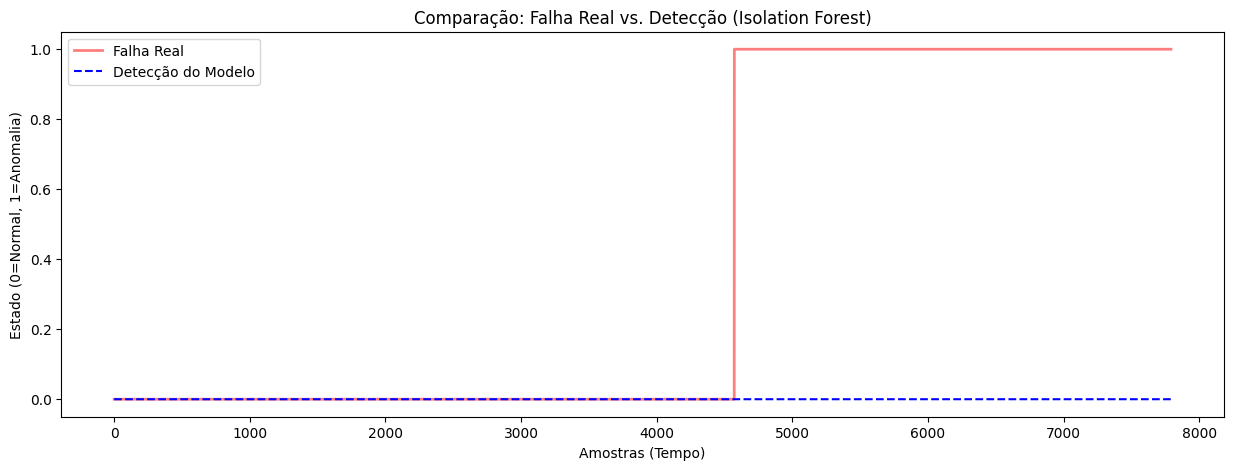

In [14]:
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()

# Seleção manual olhando os gráficos 

In [15]:
df.columns

Index(['timestamp', 'target_fault', 'dev_path_y', 'dev_path_z',
       'ctrl_yaw_rate', 'nav_heading', 'alt_global', 'vel_z_local',
       'alt_gps_fix', 'vel_x_gps', 'vel_y_gps', 'mag_x', 'mag_y', 'mag_z',
       'vel_x_odom', 'vel_y_odom', 'vel_z_odom', 'pos_x_local', 'pos_y_local',
       'pos_z_local', 'vel_x_twist', 'vel_y_twist', 'vel_z_twist', 'aspd_cmd',
       'aspd_meas', 'alt_error', 'aspd_error', 'nav_dist_wp',
       'nav_error_xtrack', 'pitch_cmd', 'pitch_meas', 'roll_cmd', 'roll_meas',
       'vel_x_des', 'vel_y_des', 'vel_z_des', 'vel_x_meas', 'vel_y_meas',
       'vel_z_meas', 'yaw_cmd', 'yaw_meas', 'yaw_rate_target', 'aspd_hud',
       'alt_hud', 'groundspeed_hud', 'wind_x', 'wind_y', 'wind_z', 'err_pitch',
       'err_roll', 'err_vel_x', 'err_vel_y', 'err_vel_z', 'err_yaw'],
      dtype='str')

In [16]:
important_cols = ['dev_path_z',
                      'vel_x_odom',
                      'vel_z_odom',
                      'pos_z_local',
                      'aspd_meas',
                      'alt_error',
                      'aspd_error',
                      'aspd_hud',
                      'alt_hud',
                      'groundspeed_hud'
                      ]

In [17]:
# Criar a lista final de colunas que desejamos manter
cols_to_keep = important_cols + [target_col]

# 2. Filtrar o DataFrame original apenas com essas colunas
df_manual_crafted = df[cols_to_keep].copy()

print(f"Novo DataFrame criado com {df_manual_crafted.shape[1]} colunas.")
print(df_rf.head())

Novo DataFrame criado com 11 colunas.
    aspd_hud  aspd_meas  alt_error     alt_hud  alt_global  yaw_rate_target  \
0  18.193935  18.193935      -2.14  382.419983  347.412387       -18.193935   
1  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
2  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
3  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
4  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   

   pos_z_local  alt_gps_fix  dev_path_z    wind_y  target_fault  
0    37.247299   350.452363   12.752701  6.901174           0.0  
1    37.247299   350.452363   12.752701  6.901174           0.0  
2    37.247299   350.452363   12.752701  6.901174           0.0  
3    37.247299   350.452363   12.752701  6.901174           0.0  
4    37.247299   350.452363   12.752701  6.901174           0.0  


In [18]:
X, y = create_windows(df_manual_crafted, window_size, important_cols, target_col)

In [19]:
X

array([[ 12.75270081,  17.89910005,   1.46697282, ...,  18.19393539,
        382.41998291,  17.79374886],
       [ 12.75270081,  17.89910005,   1.46697282, ...,  18.19393539,
        382.41998291,  17.79374886],
       [ 12.75270081,  17.89910005,   1.46697282, ...,  18.19393539,
        382.41998291,  17.79374886],
       ...,
       [ 21.67013741,   9.88338434,  -3.18753066, ...,  11.31165123,
        372.8999939 ,  10.04735279],
       [ 21.67013741,   9.88338434,  -3.18753066, ...,  11.31165123,
        372.8999939 ,  10.04735279],
       [ 21.67013741,   9.88338434,  -3.18753066, ...,  11.31165123,
        372.8999939 ,  10.04735279]], shape=(25974, 200))

--- RESULTADO DA DETECÇÃO ---
A falha foi detectada com uma latência de: 21.290 segundos

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.68      1.00      0.81      4573
         1.0       1.00      0.34      0.51      3220

    accuracy                           0.73      7793
   macro avg       0.84      0.67      0.66      7793
weighted avg       0.81      0.73      0.69      7793



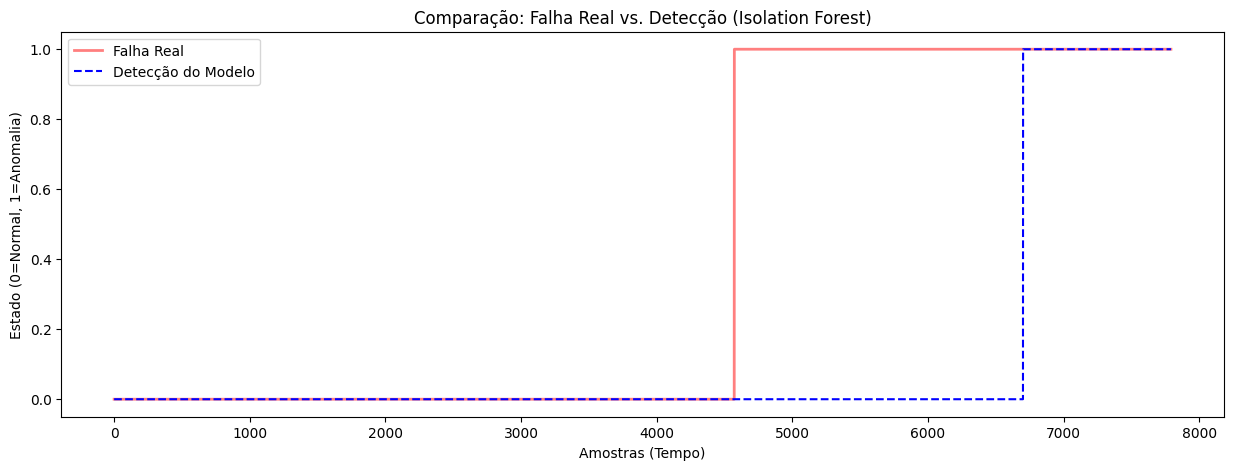

In [20]:
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()

calcular erro das variaveis

'pitch_cmd' and 'pitch_meas'
'roll_cmd' and 'roll_meas'
'velocity.des_x' and 'velocity.meas_x'
'velocity.des_y' and 'velocity.meas_y'
'velocity.des_z' and 'velocity.meas_z'
'yaw.commanded' and 'yaw.measured'

In [21]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


# Parâmetros

In [22]:
DATA_FILE = '../data/02_intermediate/carbonZ_master_0_to_8_merged.csv'

# Funções

In [23]:
def plot_flight_data_by_source(df, source_name, skip_noise=True):
    """
    df: DataFrame com o join completo
    source_name: String contida no nome das colunas (ex: 'battery' ou 'imu-data_raw')
    skip_noise: Se True, ignora colunas de covariância e metadados técnicos
    """
    # 1. Identificar colunas que pertencem a esta fonte
    # O padrão do join é: [NomeDoArquivo]_field.[Campo]
    cols = [c for c in df.columns if source_name in c and '_field.' in c]
    
    if skip_noise:
        noise_keywords = ['covariance', 'checksum', 'magic', 'seq', 'stamp', 'frame_id', 'sysid', 'compid', 'msgid']
        cols = [c for c in cols if not any(k in c.lower() for k in noise_keywords)]

    if not cols:
        print(f"Nenhuma coluna relevante encontrada para: {source_name}")
        return

    # 2. Configurar o layout dos gráficos
    n_cols = len(cols)
    fig, axes = plt.subplots(n_cols, 1, figsize=(15, 2.5 * n_cols), sharex=True)
    
    if n_cols == 1:
        axes = [axes]

    print(f"Plotando {n_cols} colunas de: {source_name}")
    
    # 3. Gerar os plots
    for i, col in enumerate(cols):
        clean_label = col.split('_field.')[-1] # Nome humano da variável
        axes[i].plot(df['%time'], df[col], label=clean_label, color='tab:blue')
        axes[i].set_ylabel(clean_label)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Time (%time)')
    plt.suptitle(f"Análise de Sensores: {source_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    
    # Salvar ou mostrar
    #plt.savefig(f"plot_{source_name.replace('-', '_')}.png")
    plt.show()

# Abrindo arquivo



In [24]:
df = pd.read_csv(DATA_FILE)


In [25]:
df

,%time,field.header.seq_x,field.header.stamp_x,field.header.frame_id_x,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,...,field.linear_acceleration_covariance6,field.linear_acceleration_covariance7,field.linear_acceleration_covariance8,vel_desejada_x,vel_desejada_y,vel_desejada_z,vel_medida_x,vel_medida_y,vel_medida_z,erro_vel_x
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,0.000000,0.000000e+00,0.000000e+00,-0.264065,19.482502,-0.006710,0.264065
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,0.000000,0.000000e+00,0.000000e+00,0.592966,19.294773,-0.907830,-0.592966
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,0.519734,18.983192,-1.659447,15.480266
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,0.134113,18.698671,-2.067202,15.865887
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,-0.092226,18.052509,-2.765224,16.092226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-1.452498,-10.838521,2.056844,1.452495
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-1.020003,-10.773220,1.998119,1.020000
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-0.519293,-10.632876,1.636550,0.519290
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-0.181130,-10.446597,1.588165,0.181127


# Descartar Colunas de Ruído

Remove-se metadados de protocolo, IDs de sistema e campos brutos do MAVLink que não possuem valor físico para o aprendizado de máquina.

In [26]:
# Lista de padrões de nomes que representam ruído/metadados
keywords_ruido = [
    'header', 'seq', 'stamp', 'frame_id', 'magic', 'len', 
    'flags', 'sysid', 'compid', 'msgid', 'checksum', 'payload'
]

# Filtrar as colunas que NÃO contêm as palavras-chave acima
cols_ruido = [col for col in df.columns if any(key in col for key in keywords_ruido)]

# Criar dataframe sem ruído (Limpando o excesso)
df_limpo = df.drop(columns=cols_ruido)

print(f"Colunas removidas: {len(cols_ruido)}")
print(f"Colunas restantes: {len(df_limpo.columns)}")

Colunas removidas: 25
Colunas restantes: 70


In [27]:
df_limpo

,%time,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,engine_status,rc_aileron,rc_elevator,...,field.linear_acceleration_covariance6,field.linear_acceleration_covariance7,field.linear_acceleration_covariance8,vel_desejada_x,vel_desejada_y,vel_desejada_z,vel_medida_x,vel_medida_y,vel_medida_z,erro_vel_x
0,1531943810933587063,19.086618,-1.989246,0.0,0.0,0.0,0.0,0,1626,1532,...,0.0,0.0,9.000000e-08,0.000000,0.000000e+00,0.000000e+00,-0.264065,19.482502,-0.006710,0.264065
1,1531943811143678844,19.315361,-0.752150,0.0,0.0,0.0,0.0,0,1626,1532,...,0.0,0.0,9.000000e-08,0.000000,0.000000e+00,0.000000e+00,0.592966,19.294773,-0.907830,-0.592966
2,1531943811338236330,19.146784,-0.350922,0.0,0.0,0.0,0.0,0,1515,1552,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,0.519734,18.983192,-1.659447,15.480266
3,1531943811549229158,18.873702,-0.487633,0.0,0.0,0.0,0.0,0,1515,1552,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,0.134113,18.698671,-2.067202,15.865887
4,1531943811742729793,18.355274,-0.416539,0.0,0.0,0.0,0.0,0,1515,1552,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,-0.092226,18.052509,-2.765224,16.092226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,-11.029684,-1.563865,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-1.452498,-10.838521,2.056844,1.452495
658,1531943942544529002,-11.015610,-1.192788,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-1.020003,-10.773220,1.998119,1.020000
659,1531943942747957693,-10.878427,-0.829410,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-0.519293,-10.632876,1.636550,0.519290
660,1531943942945854826,-10.699969,-0.463429,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-0.181130,-10.446597,1.588165,0.181127


## Renomeando colunas

In [28]:
# Dicionário de mapeamento: Nome Original -> Nome Intuitivo
mapeamento_nomes = {
    'field.twist.linear.x': 'vel_gps_x',
    'field.twist.linear.y': 'vel_gps_y',
    'field.twist.linear.z': 'vel_gps_z',
    'field.twist.angular.x': 'taxa_giro_roll',
    'field.twist.angular.y': 'taxa_giro_pitch',
    'field.twist.angular.z': 'taxa_giro_yaw',
    'engine_status': 'status_motor_log',
    'rc_aileron': 'comando_aileron',
    'rc_elevator': 'comando_profundor',
    'rc_throttle': 'comando_acelerador',
    'rc_rudder': 'comando_leme',
    'rc_signal_strength': 'forca_sinal_rc',
    'field.status.status': 'status_gps_fix',
    'field.latitude': 'latitude',
    'field.longitude': 'longitude',
    'field.altitude': 'altitude_msl',
    'field.position_covariance0': 'incerteza_gps_horizontal',
    'field.angular_velocity.x': 'vel_angular_x',
    'field.angular_velocity.y': 'vel_angular_y',
    'field.angular_velocity.z': 'vel_angular_z',
    'field.linear_acceleration.x': 'aceleracao_x_frontal',
    'field.linear_acceleration.y': 'aceleracao_y_lateral',
    'field.linear_acceleration.z': 'aceleracao_z_vertical',
    'field.linear_acceleration_covariance0': 'ruido_acelerometro_x',
    'field.linear_acceleration_covariance4': 'ruido_acelerometro_y',
    'field.linear_acceleration_covariance8': 'ruido_acelerometro_z'
}

# Renomeando no DataFrame
df_limpo = df_limpo.rename(columns=mapeamento_nomes)

# Verificando os novos nomes
print("Colunas renomeadas:")
print(df_limpo.columns.tolist())

Colunas renomeadas:
['%time', 'vel_gps_x', 'vel_gps_y', 'vel_gps_z', 'taxa_giro_roll', 'taxa_giro_pitch', 'taxa_giro_yaw', 'status_motor_log', 'comando_aileron', 'comando_profundor', 'comando_acelerador', 'comando_leme', 'forca_sinal_rc', 'field.framing_status', 'status_gps_fix', 'field.status.service', 'latitude', 'longitude', 'altitude_msl', 'incerteza_gps_horizontal', 'field.position_covariance1', 'field.position_covariance2', 'field.position_covariance3', 'field.position_covariance4', 'field.position_covariance5', 'field.position_covariance6', 'field.position_covariance7', 'field.position_covariance8', 'field.position_covariance_type', 'altitude_relativa', 'field.orientation_covariance0', 'field.orientation_covariance1', 'field.orientation_covariance2', 'field.orientation_covariance3', 'field.orientation_covariance4', 'field.orientation_covariance5', 'field.orientation_covariance6', 'field.orientation_covariance7', 'field.orientation_covariance8', 'vel_angular_x', 'vel_angular_y', 

# Limpeza extra

In [29]:
df_limpo = df_limpo.drop_duplicates()

df_limpo = df_limpo.dropna(subset=['%time'])

# Converter %time para segundos relativos 
# Isso faz o tempo começar em 0
df_limpo['tempo_relativo'] = (df_limpo['%time'] - df_limpo['%time'].iloc[0]) / 1e9 

print(f"Dataset limpo: {df_limpo.shape[0]} linhas prontas.")

Dataset limpo: 662 linhas prontas.


# Contagem de nulos por coluna

In [30]:
# Contagem total de nulos por coluna
nulos_por_coluna = df_limpo.isnull().sum()

# Filtrar apenas as colunas que possuem pelo menos um nulo para facilitar a leitura
colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0]

preencher_nans = False

print("Contagem de valores nulos antes do tratamento:")
if not colunas_com_nulos.empty:
    print(colunas_com_nulos)
    if preencher_nans:
        # Usamos ffill (preencher com o anterior) e bfill (preencher com o próximo) 
        # para garantir que não restem valores nulos após o merge
        df_limpo = df_limpo.ffill().bfill()
else:
    print("Nenhum valor nulo encontrado!")

Contagem de valores nulos antes do tratamento:
Nenhum valor nulo encontrado!


# Normalização

Usa-se o MinMaxScaler que é excelente para Redes Neurais e Autoencoders, pois garante que nenhum valor escape do intervalo definido..

In [31]:
# 1. Selecionar colunas (exceto tempo)
cols_treino = [c for c in df_limpo.columns if c not in ['%time', 'tempo_relativo']]

# 2. Aplicar MinMaxScaler (Garante intervalo entre 0 e 1)
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
df_norm = df_limpo.copy()

# Forçamos a conversão para float para evitar erros de tipo
df_norm[cols_treino] = scaler_minmax.fit_transform(df_limpo[cols_treino].astype(float))

# 3. VALIDAÇÃO: Agora o máximo TEM que ser 1 e o mínimo TEM que ser 0
print("--- Verificação de Intervalo Fixo ---")
print(f"Valor Máximo: {df_norm[cols_treino].max().max()}")
print(f"Valor Mínimo: {df_norm[cols_treino].min().min()}")

--- Verificação de Intervalo Fixo ---
Valor Máximo: 1.0000000000000004
Valor Mínimo: 0.0


In [32]:
output_dir = '../data/03_primary'

# Salvar o dataframe completo (Master)
file_path = os.path.join(output_dir, 'carbonZ_master_normalizado_sem_colunas_ruido.csv')
df_norm.to_csv(file_path, index=False)

print(f"Dataset mestre salvo com sucesso em: {file_path}")

Dataset mestre salvo com sucesso em: ../data/03_primary/carbonZ_master_normalizado_sem_colunas_ruido.csv


# Primeira filtragem de features para modelagem

Foca-se nas colunas que descrevem a física do voo e a intenção do piloto, essenciais para o modelo semi-supervisionado detectar anomalias.

In [33]:
# Seleção estratégica de colunas para Detecção de Falhas (Engine Failure)
features_treino = [
    '%time',                   # Essencial para séries temporais
    'rc_throttle',             # Causa (Comando)
    'rc_elevator',             # Causa (Comando)
    'rc_aileron',              # Causa (Comando)
    'field.linear_acceleration.x', # Efeito imediato (Física)
    'field.angular_velocity.y',    # Efeito imediato (Atitude/Pitch)
    'vel_medida_x',            # Estado atual
    'erro_vel_x',              # Feature de Ouro (Desvio de performance)
    'altitude_relativa',       # Estado atual (Sustentação)
    'field.twist.linear.z',    # Taxa de subida/descida real
    'field.linear_acceleration_covariance0', # Saúde do sensor/Vibração
    'field.position_covariance0'             # Integridade do GPS (Útil para ataques)
]

# Criar o DataFrame final de treinamento
df_modelo = df_limpo[features_treino].copy()

# Opcional: Remover os primeiros NaNs (delay de inicialização dos sensores)
df_modelo = df_modelo.dropna().reset_index(drop=True)

print("Colunas selecionadas para o modelo:")
print(df_modelo.columns.tolist())

KeyError: "['rc_throttle', 'rc_elevator', 'rc_aileron', 'field.linear_acceleration.x', 'field.angular_velocity.y', 'field.twist.linear.z', 'field.linear_acceleration_covariance0', 'field.position_covariance0'] not in index"

In [ ]:
df_modelo.shape